In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore') 

In [3]:
lp=pd.read_csv("C:/Users/sweth/Downloads/loan_prediction_dataset.csv")
lp

,age,income,credit_score,dependents,home_owner,loan_approved
0,54,100000.00,334,0,1,1
1,67,85233.42,593,2,1,1
2,29,16737.15,502,0,0,1
3,42,69332.50,367,3,0,0
4,58,28211.14,430,0,1,1
...,...,...,...,...,...,...
995,68,18279.98,379,3,0,0
996,41,8244.06,653,4,1,1
997,39,16194.69,460,2,1,1
998,52,38739.91,726,2,1,1


In [4]:
lp.head()

,age,income,credit_score,dependents,home_owner,loan_approved
0,54,100000.00,334,0,1,1
1,67,85233.42,593,2,1,1
2,29,16737.15,502,0,0,1
3,42,69332.50,367,3,0,0
4,58,28211.14,430,0,1,1


In [5]:
lp.tail()

,age,income,credit_score,dependents,home_owner,loan_approved
995,68,18279.98,379,3,0,0
996,41,8244.06,653,4,1,1
997,39,16194.69,460,2,1,1
998,52,38739.91,726,2,1,1
999,24,11278.55,702,0,0,1


In [6]:
lp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1000 non-null   int64  
 1   income         1000 non-null   float64
 2   credit_score   1000 non-null   int64  
 3   dependents     1000 non-null   int64  
 4   home_owner     1000 non-null   int64  
 5   loan_approved  1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [7]:
print("Columns:",lp.columns)

Columns: Index(['age', 'income', 'credit_score', 'dependents', 'home_owner',
       'loan_approved'],
      dtype='object')


In [9]:
print("Shape:",lp.shape)

Shape: (1000, 6)


In [10]:
lp.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,44.54400,13.953450,20.0,33.000,44.000,57.000,69.0
income,1000.0,31943.24059,28058.315386,4000.0,11057.325,21712.035,42369.575,100000.0
credit_score,1000.0,573.64400,163.781078,300.0,423.500,572.000,720.000,849.0
dependents,1000.0,2.02700,1.422074,0.0,1.000,2.000,3.000,4.0
home_owner,1000.0,0.49400,0.500214,0.0,0.000,0.000,1.000,1.0
loan_approved,1000.0,0.78200,0.413094,0.0,1.000,1.000,1.000,1.0


In [11]:
lp.dtypes

age                int64
income           float64
credit_score       int64
dependents         int64
home_owner         int64
loan_approved      int64
dtype: object

In [13]:
lp.isnull().sum()

age              0
income           0
credit_score     0
dependents       0
home_owner       0
loan_approved    0
dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

# Features and Target
X = lp.drop("loan_approved", axis=1)
y = lp["loan_approved"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape) 
print("Train Labels:", y_train.shape)
print("Test Labels :", y_test.shape) 

Train Shape: (800, 5)
Test Shape : (200, 5)
Train Labels: (800,)
Test Labels : (200,)


In [19]:
#verify the class distribution
print("Training Set")
print(y_train.value_counts())

print("\nTesting Set")
print(y_test.value_counts())

Training Set
loan_approved
1    626
0    174
Name: count, dtype: int64

Testing Set
loan_approved
1    156
0     44
Name: count, dtype: int64


In [21]:
print("Before:", lp.shape)

new_born = lp.drop_duplicates()

print("After:", lp.shape) 

Before: (1000, 6)
After: (1000, 6)


In [22]:
from sklearn.preprocessing import StandardScaler
import joblib

# Initialize scaler 
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)

Feature scaling completed successfully!
Training Shape: (800, 5)
Testing Shape : (200, 5)


In [23]:
#Save and Verify Scaler

joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

loaded_scaler = joblib.load("scaler.pkl")
print(type(loaded_scaler)) 

Scaler saved successfully!
<class 'sklearn.preprocessing._data.StandardScaler'>


In [24]:
#SMOTE
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply only on training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
) 

print("SMOTE applied successfully!")

print("\nBefore SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_resampled.value_counts()) 

SMOTE applied successfully!

Before SMOTE
loan_approved
1    626
0    174
Name: count, dtype: int64

After SMOTE
loan_approved
0    626
1    626
Name: count, dtype: int64


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score)
# Train Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr)) 

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lr)) 

Accuracy : 0.875
Precision: 0.9781021897810219
Recall   : 0.8589743589743589
F1 Score : 0.9146757679180887

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.93      0.77        44
           1       0.98      0.86      0.91       156

    accuracy                           0.88       200
   macro avg       0.81      0.90      0.84       200
weighted avg       0.91      0.88      0.88       200


Confusion Matrix
[[ 41   3]
 [ 22 134]]

ROC-AUC: 0.9382284382284382


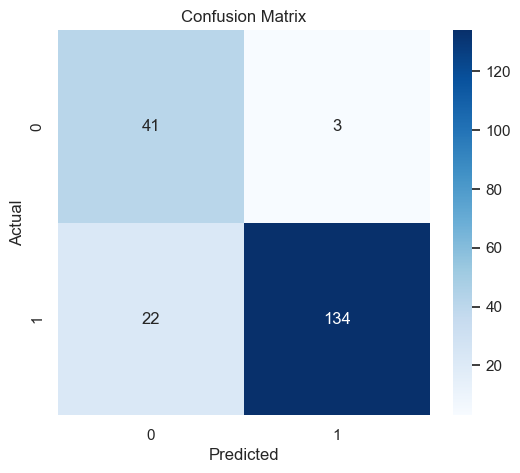

In [26]:
#CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test,y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_dt))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_dt))

Accuracy: 0.83
Precision: 0.9013157894736842
Recall   : 0.8782051282051282
F1 Score : 0.8896103896103896

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.66      0.63        44
           1       0.90      0.88      0.89       156

    accuracy                           0.83       200
   macro avg       0.75      0.77      0.76       200
weighted avg       0.84      0.83      0.83       200

Confusion Matrix:
[[ 29  15]
 [ 19 137]]

ROC-AUC: 0.7686480186480187


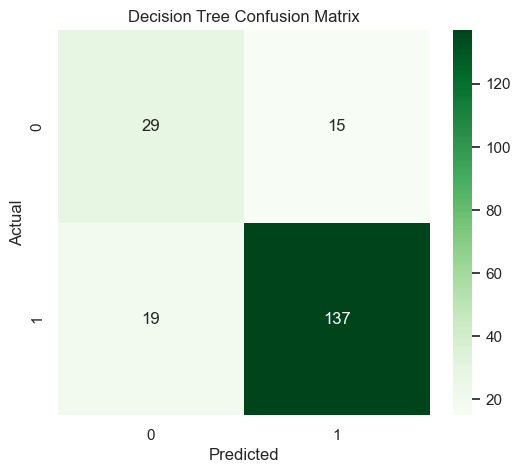

In [28]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42,n_estimators=100)

rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.85
Precision: 0.9090909090909091
Recall   : 0.8974358974358975
F1 Score : 0.9032258064516129

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.68      0.67        44
           1       0.91      0.90      0.90       156

    accuracy                           0.85       200
   macro avg       0.78      0.79      0.78       200
weighted avg       0.85      0.85      0.85       200


Confusion Matrix:
[[ 30  14]
 [ 16 140]]

ROC-AUC: 0.9068327505827506


In [30]:
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy :", rf_model.score(X_test, y_test))

Training Accuracy: 0.7825
Testing Accuracy : 0.78


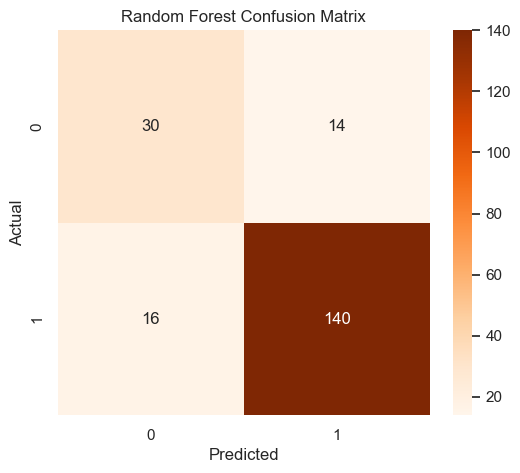

In [31]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42,eval_metric="logloss")

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.85
Precision: 0.92
Recall   : 0.8846153846153846
F1 Score : 0.9019607843137255

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.73      0.68        44
           1       0.92      0.88      0.90       156

    accuracy                           0.85       200
   macro avg       0.78      0.81      0.79       200
weighted avg       0.86      0.85      0.85       200


Confusion Matrix:
[[ 32  12]
 [ 18 138]]

ROC-AUC: 0.9106934731934732


In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_resampled, y_train_resampled)

y_pred_knn = knn_model.predict(X_test_scaled) 
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_knn)) 



Accuracy: 0.84
Precision: 0.9558823529411765
Recall   : 0.8333333333333334
F1 Score : 0.8904109589041096

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.86      0.70        44
           1       0.96      0.83      0.89       156

    accuracy                           0.84       200
   macro avg       0.77      0.85      0.80       200
weighted avg       0.88      0.84      0.85       200


Confusion Matrix:
[[ 38   6]
 [ 26 130]]

ROC-AUC: 0.8830128205128205


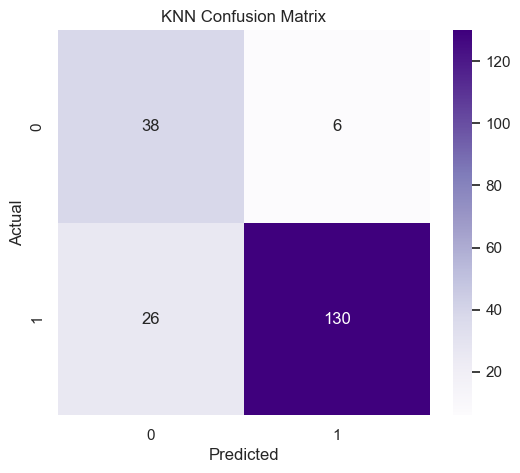

In [34]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf",probability=True,random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_svm))

Accuracy: 0.87
Precision: 0.9642857142857143
Recall   : 0.8653846153846154
F1 Score : 0.9121621621621622

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75        44
           1       0.96      0.87      0.91       156

    accuracy                           0.87       200
   macro avg       0.81      0.88      0.83       200
weighted avg       0.90      0.87      0.88       200


Confusion Matrix:
[[ 39   5]
 [ 21 135]]

ROC-AUC: 0.9280303030303031


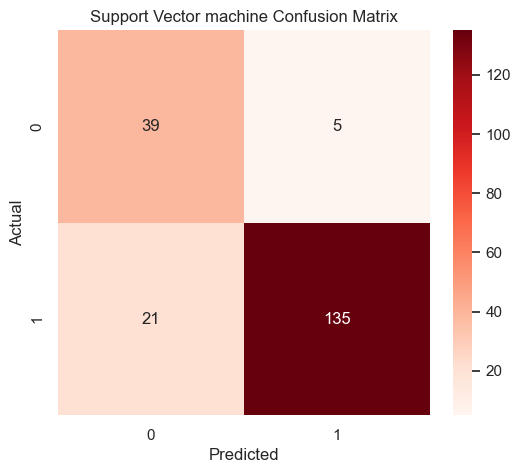

In [36]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')

plt.title("Support Vector machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual") 
plt.show() 

In [37]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Store model names and trained models
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "KNN": knn_model,
    "SVM": svm_model
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.875,0.978102,0.858974,0.914676,0.938228
1,SVM,0.870,0.964286,0.865385,0.912162,0.928030
2,Random Forest,0.850,0.909091,0.897436,0.903226,0.906833
3,XGBoost,0.850,0.920000,0.884615,0.901961,0.910693
4,KNN,0.840,0.955882,0.833333,0.890411,0.883013
5,Decision Tree,0.830,0.901316,0.878205,0.889610,0.768648


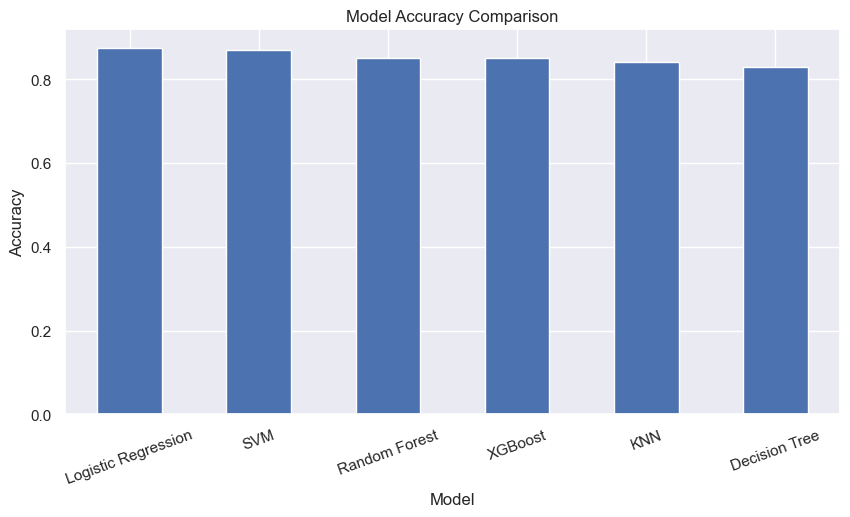

In [38]:
#Visual Comparision 
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'sag'],
    'max_iter': [1000, 2000, 3000, 5000]
}

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        random_state=42
    ),
    param_distributions=lr_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train_resampled, y_train_resampled)

best_lr = lr_search.best_estimator_

print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

Best Logistic Regression Parameters:
{'solver': 'newton-cg', 'max_iter': 2000, 'C': 0.1}


In [65]:
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)

print("Tuned Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(
          y_test,
          y_pred_lr,
          average='weighted',
          zero_division=0
      ))

print("Recall   :",
      recall_score(
          y_test,
          y_pred_lr,
          average='weighted',
          zero_division=0
      ))

print("F1 Score :",
      f1_score(
          y_test,
          y_pred_lr,
          average='weighted',
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nROC-AUC:",
      roc_auc_score(
          y_test,
          y_pred_lr,
          multi_class='ovr',
          average='weighted'
      ))

Tuned Logistic Regression Results
Accuracy : 0.865
Precision: 0.9061811244529234
Recall   : 0.865
F1 Score : 0.8736145141681473

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.95      0.76        44
           1       0.98      0.84      0.91       156

    accuracy                           0.86       200
   macro avg       0.81      0.90      0.83       200
weighted avg       0.91      0.86      0.87       200


Confusion Matrix:
[[ 42   2]
 [ 25 131]]

ROC-AUC: 0.8971445221445222


In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid 
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
} 

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params, 
    cv=5,
    scoring="accuracy", 
    n_jobs=-1
) 

dt_grid.fit(X_train_resampled, y_train_resampled)

best_dt = dt_grid.best_estimator_

print("Best Parameters:", dt_grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [40]:
#Evaluate Tuned Decision Tree
y_pred_dt = best_dt.predict(X_test_scaled)
y_prob_dt = best_dt.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:") 
print(confusion_matrix(y_test, y_pred_dt))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_dt)) 

Accuracy: 0.82
Precision: 0.8947368421052632
Recall: 0.8717948717948718
F1 Score: 0.8831168831168831

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.64      0.61        44
           1       0.89      0.87      0.88       156

    accuracy                           0.82       200
   macro avg       0.74      0.75      0.75       200
weighted avg       0.83      0.82      0.82       200


Confusion Matrix:
[[ 28  16]
 [ 20 136]]

ROC-AUC: 0.7848921911421909


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_resampled, y_train_resampled)

best_rf = rf_search.best_estimator_

print("Best Parameters:", rf_search.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [42]:
#Evaluate Tuned Decision Tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.85
Precision: 0.9144736842105263
Recall   : 0.8910256410256411
F1 Score : 0.9025974025974026

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67        44
           1       0.91      0.89      0.90       156

    accuracy                           0.85       200
   macro avg       0.78      0.80      0.79       200
weighted avg       0.86      0.85      0.85       200


Confusion Matrix:
[[ 31  13]
 [ 17 139]]

ROC-AUC: 0.9093822843822844


In [43]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter Grid
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_resampled, y_train_resampled)

best_xgb = xgb_search.best_estimator_

print("Best Parameters:", xgb_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [44]:
#Evaluate Tuned XGBOOST
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb)) 

Accuracy: 0.855
Precision: 0.9205298013245033
Recall   : 0.8910256410256411
F1 Score : 0.9055374592833876

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69        44
           1       0.92      0.89      0.91       156

    accuracy                           0.85       200
   macro avg       0.79      0.81      0.80       200
weighted avg       0.86      0.85      0.86       200


Confusion Matrix:
[[ 32  12]
 [ 17 139]]

ROC-AUC: 0.918997668997669


In [55]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

svm_search = RandomizedSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_distributions=svm_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_train_resampled, y_train_resampled)

best_svm = svm_search.best_estimator_

print("Best SVM Parameters:")
print(svm_search.best_params_)

Best SVM Parameters:
{'kernel': 'rbf', 'gamma': 'scale', 'C': 100}


In [56]:
#Evaluate Tuned SVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_svm))

Accuracy: 0.855
Precision: 0.9440559440559441
Recall   : 0.8653846153846154
F1 Score : 0.903010033444816

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.82      0.71        44
           1       0.94      0.87      0.90       156

    accuracy                           0.85       200
   macro avg       0.79      0.84      0.81       200
weighted avg       0.88      0.85      0.86       200


Confusion Matrix:
[[ 36   8]
 [ 21 135]]

ROC-AUC: 0.9045745920745921


In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=knn_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

knn_search.fit(X_train_resampled, y_train_resampled)

best_knn = knn_search.best_estimator_

print("Best KNN Parameters:")
print(knn_search.best_params_)

Best KNN Parameters:
{'weights': 'distance', 'p': 2, 'n_neighbors': 5, 'metric': 'manhattan'}


In [61]:
y_pred_knn = best_knn.predict(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)

print("Tuned KNN Results")


print("Accuracy :", accuracy_score(y_test, y_pred_knn))

print("Precision:",
      precision_score(
          y_test,
          y_pred_knn,
          average='weighted',
          zero_division=0
      ))

print("Recall   :",
      recall_score(
          y_test,
          y_pred_knn,
          average='weighted',
          zero_division=0
      ))

print("F1 Score :",
      f1_score(
          y_test,
          y_pred_knn,
          average='weighted',
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nROC-AUC:",
      roc_auc_score(
          y_test,
          y_pred_knn,
          multi_class='ovr',
          
      ))

Tuned KNN Results
Accuracy : 0.845
Precision: 0.8699819689866571
Recall   : 0.845
F1 Score : 0.8523722663528488

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.82      0.70        44
           1       0.94      0.85      0.90       156

    accuracy                           0.84       200
   macro avg       0.78      0.84      0.80       200
weighted avg       0.87      0.84      0.85       200


Confusion Matrix:
[[ 36   8]
 [ 23 133]]

ROC-AUC: 0.8353729603729603


In [45]:
from sklearn.model_selection import cross_val_score


In [69]:
from sklearn.model_selection import cross_val_score
import pandas as pd

models = { 
    "Logistic Regression": best_lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "SVM": best_svm,
    "KNN": best_knn    
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Cross Validation Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    by="Cross Validation Accuracy",
    ascending=False
).reset_index(drop=True)
 
cv_df

,Model,Cross Validation Accuracy,Standard Deviation
0,Logistic Regression,0.91000,0.023251
1,Random Forest,0.90750,0.015000
2,SVM,0.90500,0.016956
3,XGBoost,0.90375,0.017048
4,KNN,0.90125,0.013346
5,Decision Tree,0.89250,0.020691


In [47]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

scores_dt = cross_val_score(best_dt,X,y,cv=5,scoring='accuracy')

print("Decision Tree Cross Validation Scores:",scores_dt)
print("Average Accuracy:", scores_dt.mean())
print("Standard Deviation:", scores_dt.std())


Decision Tree Cross Validation Scores: [0.895 0.89  0.82  0.865 0.84 ]
Average Accuracy: 0.8619999999999999
Standard Deviation: 0.028740215726399856


In [48]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

scores_rf = cross_val_score(best_rf,X,y,cv=5,scoring='accuracy')

print("Random Forest Cross Validation Scores:",scores_rf)
print("Average Accuracy:", scores_rf.mean())
print("Standard Deviation:", scores_rf.std()) 


Random Forest Cross Validation Scores: [0.91  0.885 0.875 0.88  0.88 ]
Average Accuracy: 0.8859999999999999
Standard Deviation: 0.012409673645990866


In [49]:
scores_xgb = cross_val_score(best_xgb,X,y,cv=5,scoring='accuracy')

print("XGBOOST Cross Validation Scores:",scores_xgb) 
print("Average Accuracy:", scores_xgb.mean())
print("Standard Deviation:", scores_xgb.std()) 


XGBOOST Cross Validation Scores: [0.91  0.895 0.88  0.905 0.87 ]
Average Accuracy: 0.892
Standard Deviation: 0.015033296378372923


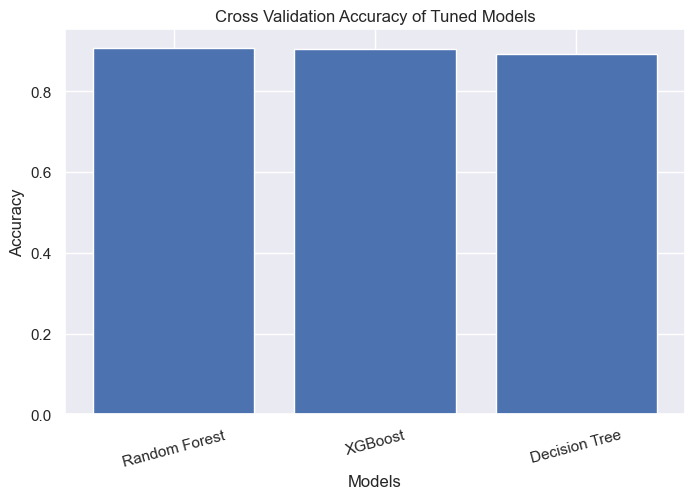

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    cv_df["Model"],
    cv_df["Cross Validation Accuracy"]
)

plt.title("Cross Validation Accuracy of Tuned Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,credit_score,0.516086
3,dependents,0.192834
1,income,0.172318
0,age,0.087675
4,home_owner,0.031087


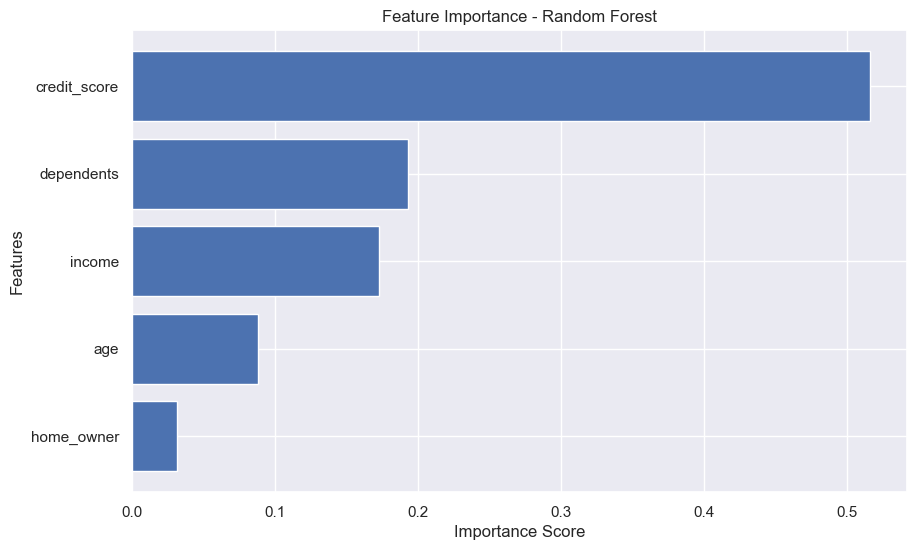

In [52]:
#Visualise
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"] 
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [70]:
import joblib  

joblib.dump(best_lr, "logistic_regression_model.pkl")

print("Logistic Regression model saved successfully.")  

Logistic Regression model saved successfully.


In [72]:
#Verify the model
loaded_model = joblib.load("logistic_regression_model.pkl")
         
print(type(loaded_model))  

<class 'sklearn.linear_model._logistic.LogisticRegression'>
